In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,24.12740,40.28807,2010-01-01,κεντρικης μακεδονιας,αθως,28,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,NaN,NaN,NaN,46.96020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.642500,15.530000,9.755000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,34.075000,97.500000,0.575000,741.395353,5480.994362,0,229.615930,142.067691,199.028237,134451.168165,1.385666,1,0,0
1,22.41314,40.63121,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.705000,12.360000,7.050000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.800000,40.250000,0.000000,19302.853155,218.518170,4,165.845298,4.439405,180.217997,0.000000,252.542758,1,0,0
2,22.07467,40.99173,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,13,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.55763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.388182,9.579091,5.197273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,20.218182,39.590909,0.045455,23100.611480,687.499343,0,127.752566,125.810202,179.704207,0.000000,1.162002,1,0,0
3,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,15.000000,39.900000,0.000000,783.725557,1072.158690,3,157.852939,3.721570,180.299131,0.000000,56.126569,3,0,0
4,23.97067,40.91960,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,35,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.135000,12.090000,8.180000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,20.225000,29.825000,0.000000,16692.000632,304.097354,4,255.084988,347.388991,187.472171,0.000000,20.820754,1,0,0


In [6]:
#Check months

dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,24.12740,40.28807,2010-06-01,κεντρικης μακεδονιας,αθως,28,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,NaN,NaN,NaN,46.96020,0.611042,0.290200,-0.256582,-0.290200,0.583645,0.252755,-0.263438,-0.252755,0.046099,0.057701,0.020908,0.057701,20.160000,21.960000,18.360000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,40.375000,67.475000,304.300000,741.395353,5480.994362,0,229.615930,142.067691,199.028237,134451.168165,1.385666,14,8,0
1,22.41314,40.63121,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.40306,0.292224,-0.001930,-0.325585,0.001930,0.315727,0.018075,-0.319086,-0.018075,0.088173,0.067612,0.026115,0.067612,26.800000,36.670000,16.930000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.150000,35.800000,270.250000,19302.853155,218.518170,4,165.845298,4.439405,180.217997,0.000000,252.542758,33,177,0
2,22.07467,40.99173,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,13,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.55763,0.586834,0.261871,-0.308051,-0.261871,0.622966,0.290016,-0.304386,-0.290016,0.055258,0.044192,0.027387,0.044192,17.649091,22.820909,12.477273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,9.736364,25.290909,221.545455,23100.611480,687.499343,0,127.752566,125.810202,179.704207,0.000000,1.162002,13,47,0
3,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,30.400000,49.500000,272.400000,783.725557,1072.158690,3,157.852939,3.721570,180.299131,0.000000,56.126569,78,284,0
4,23.97067,40.91960,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,35,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42369,0.432507,0.162274,-0.256399,-0.162274,0.484736,0.268378,-0.178337,-0.268378,0.056179,0.056793,0.032383,0.056793,25.407500,32.250000,18.565000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,14.500000,22.900000,268.550000,16692.000632,304.097354,4,255.084988,347.388991,187.472171,0.000000,20.820754,10,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4971,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,669.2,56918.0,94.3,46.54426,0.405865,0.142029,-0.351967,-0.142029,0.468400,0.183094,-0.395499,-0.183094,0.080291,0.063893,0.070824,0.063893,25.944000,31.978000,19.910000,10.737173,0.059318,12.899289,1.625429,19.773423,6.003841,26.918608,12.158944,0.260000,4.240000,368.360000,23256.650456,1174.627740,5,199.753877,62.743141,181.447326,0.000000,6.885450,22,99,1
4972,22.32761,40.83927,2018-08-16,κεντρικης μακεδονιας,πελλας,12,16,8,33,2018,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,669.2,56918.0,94.3,46.54426,

In [8]:
dataset['lau1'].unique().shape

(39,)

In [9]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,301,250,551,11.07%
1,2011,366,31,397,7.98%
2,2012,371,20,391,7.86%
3,2013,373,21,394,7.92%
4,2014,390,0,390,7.84%
5,2015,390,0,390,7.84%
6,2016,390,0,390,7.84%
7,2017,390,0,390,7.84%
8,2018,321,117,438,8.80%
9,2019,354,53,407,8.18%


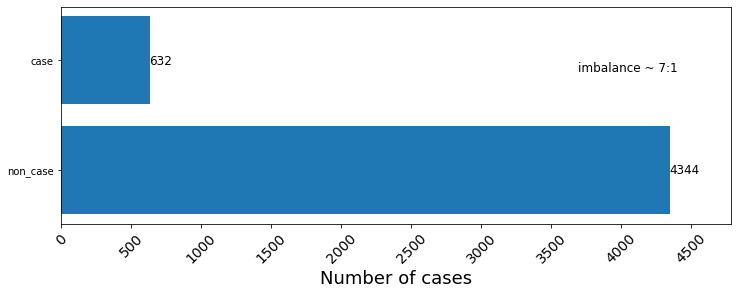

In [10]:
plot_imbalance(dataset)

In [11]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [12]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:4 || ##
Year: 2011 || w0:1, w1:3 || ##
Year: 2012 || w0:1, w1:3 || ##
Year: 2013 || w0:1, w1:3 || ##
Year: 2014 || w0:1, w1:3 || ##
Year: 2015 || w0:1, w1:3 || ##
Year: 2016 || w0:1, w1:3 || ##
Year: 2017 || w0:1, w1:3 || ##
Year: 2018 || w0:1, w1:3 || ##
Year: 2019 || w0:1, w1:3 || ##
Year: 2020 || w0:1, w1:3 || ##
Year: 2021 || w0:1, w1:3 || ##


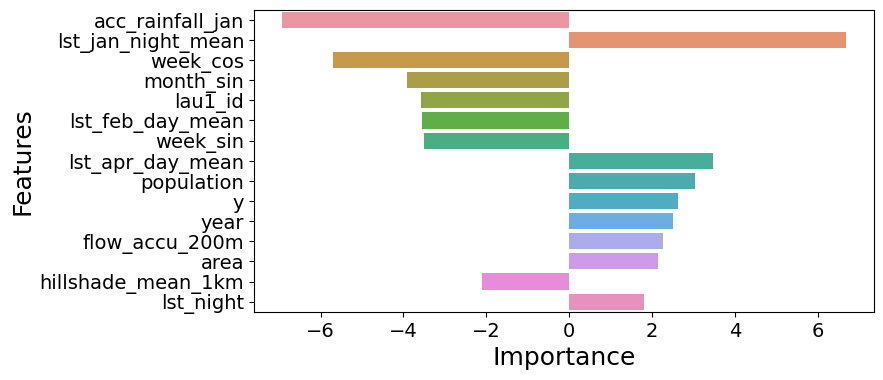

In [13]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

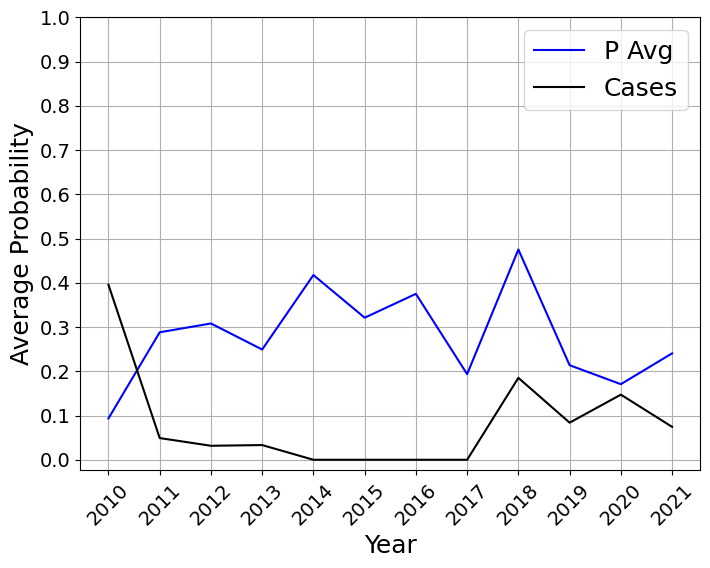

In [14]:
plot_trend_curve(results_test, list(dsc['case']))

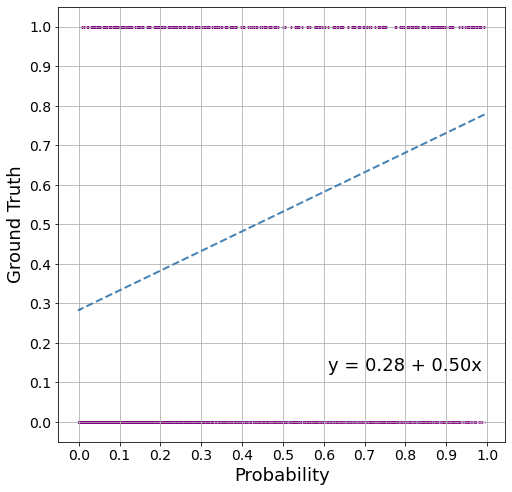

In [15]:
plot_probability_curve(results_test)

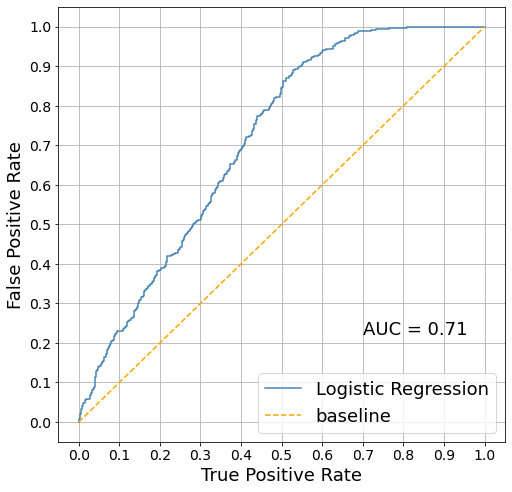

In [16]:
plot_roc_curve(results_test)

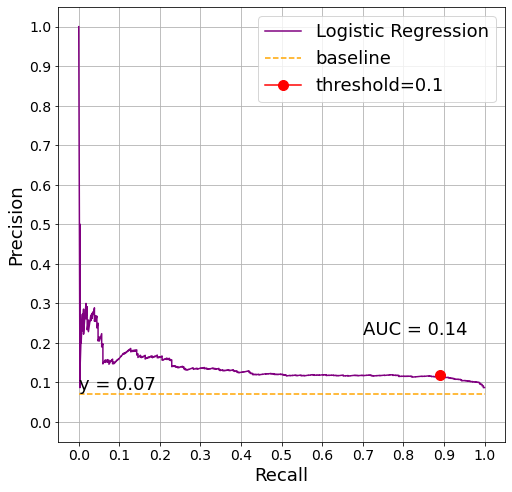

In [25]:
plot_pr_curve(results_test, plot_fbeta=True)

In [18]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 35.74%
Weighted Average: 40.77%


In [19]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,1,0,1,0.00 %,0.00
3,16/07/2010,12,3,5,60.00 %,0.60
4,01/08/2010,23,4,5,80.00 %,0.80
...,...,...,...,...,...,...
115,16/08/2021,8,3,5,60.00 %,0.60
116,01/09/2021,4,1,4,25.00 %,0.25
117,16/09/2021,1,1,1,100.00 %,1.00
118,01/10/2021,1,0,1,0.00 %,0.00


In [20]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,89,17,26,65.38 %,0.6538
1,2011,24,6,20,30.00 %,0.3000
2,2012,19,2,19,10.53 %,0.1053
3,2013,17,7,17,41.18 %,0.4118
4,2014,0,0,0,nan %,NaN
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,69,15,34,44.12 %,0.4412
9,2019,36,5,24,20.83 %,0.2083


In [26]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [27]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.3282,0.8333,0.5859,0.8427,0.8215,0.4303
1,2011,24.0,0.5615,0.7114,0.1050,0.9583,0.6484,0.4514
2,2012,19.0,0.5872,0.6617,0.0742,0.8947,0.5422,0.6154
3,2013,17.0,0.5436,0.7079,0.0755,0.9412,0.5620,0.3735
4,2014,0.0,0.6846,0.3154,0.0000,0.0000,0.0000,0.8377
5,2015,0.0,0.5692,0.4308,0.0000,0.0000,0.0000,0.5684
6,2016,0.0,0.6410,0.3590,0.0000,0.0000,0.0000,0.6980
7,2017,0.0,0.4872,0.5128,0.0000,0.0000,0.0000,0.2814
8,2018,69.0,0.7974,0.6142,0.2186,0.9855,0.8170,0.7417
9,2019,36.0,0.5308,0.7126,0.1594,0.9167,0.7165,0.3754


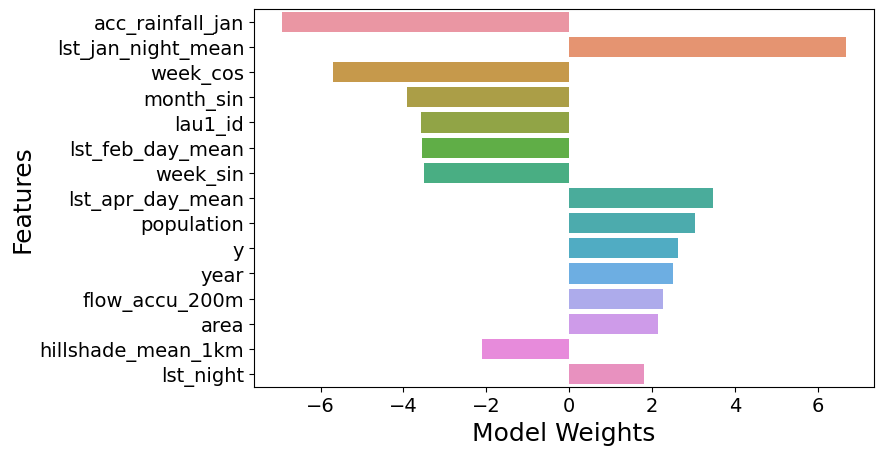

In [28]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))